# Ch 4 — 鏈式法則 & 乘積法則 (Chain Rule & Product Rule)

> 來自 3Blue1Brown《微積分的本質》第四章

> 這一章是**整個微積分裡最重要的一章**——因為**反向傳播 = 鏈式法則的反覆套用**。
> 把這一章做透，後面看 PyTorch 的 `loss.backward()` 你會「啊，這就是我會的東西」。

本筆記涵蓋：
1. 加法法則：暖身
2. 乘積法則：「面積擴張」的幾何直觀
3. 鏈式法則：「速度乘以速度」的直觀
4. 三個法則的數值驗證
5. 視覺化複合函數的導數
6. 手寫一個迷你 autograd（10 行 Python 重現 PyTorch 的核心）
7. 練習區
8. 總結與深度學習連結

## Part 0：環境設定

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def central_diff(f, x, h=1e-5):
    """中央差分數值微分（Ch 2 證明過誤差最小）"""
    return (f(x + h) - f(x - h)) / (2 * h)


def setup_ax(ax, title=""):
    ax.grid(True, linewidth=0.3)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    if title:
        ax.set_title(title)
    return ax


print("Helpers loaded ✓")

Helpers loaded ✓


## Part 1：加法法則（暖身）

### 理論

$$\frac{d}{dx}\big[f(x) + g(x)\big] = f'(x) + g'(x)$$

直觀：你把兩個獨立變化的東西加起來，**它們的變化率也直接加起來**——沒有任何驚喜。

### 為什麼要先講它？

因為它**最簡單**，也是後面兩個法則的「對照組」——乘法為什麼**不能**像加法這麼直接？這個問題就是進入乘積法則的入口。

In [2]:
# === 實驗 1：加法法則的數值驗證 ===
def f(x): return x ** 2          # f'(x) = 2x
def g(x): return np.sin(x)       # g'(x) = cos(x)
def fg_sum(x): return f(x) + g(x)  # (f+g)'(x) = 2x + cos(x)

x0 = 1.5

lhs = central_diff(fg_sum, x0)              # (f+g)'(x)
rhs = central_diff(f, x0) + central_diff(g, x0)  # f'(x) + g'(x)

print(f"在 x = {x0}：")
print(f"  (f+g)'(x)        = {lhs:.10f}")
print(f"  f'(x) + g'(x)    = {rhs:.10f}")
print(f"  解析：2x + cos(x) = {2*x0 + np.cos(x0):.10f}")
print(f"  誤差              = {abs(lhs - rhs):.2e}  ✓")

在 x = 1.5：
  (f+g)'(x)        = 3.0707372017
  f'(x) + g'(x)    = 3.0707372017
  解析：2x + cos(x) = 3.0707372017
  誤差              = 1.11e-11  ✓


## Part 2：乘積法則——「面積擴張」的幾何直觀

### 理論

$$\frac{d}{dx}\big[f(x) \cdot g(x)\big] = f'(x)\,g(x) + f(x)\,g'(x)$$

注意它**不是** $f'(x) g'(x)$！為什麼？

### 3B1B 的關鍵視覺：把乘積看成「矩形面積」

想像一個矩形：
- **寬** = $f(x)$
- **高** = $g(x)$
- **面積** = $f(x) \cdot g(x)$

當 $x$ 微微增加 $dx$：
- 寬增加 $df = f'(x)\,dx$
- 高增加 $dg = g'(x)\,dx$

矩形面積的增加量分成 **三塊**：

```
            +-------------+--------+
            |             |        |
   原 g(x)  |   原矩形    |  右條   |  ← f(x) · dg
            |             |        |
            +-------------+--------+
              df 那條     |   小角  |  ← df · dg（高階小量）
            +-------------+--------+
                  ↑
              g(x) · df
```

| 區塊 | 面積貢獻 |
|---|---|
| 右側長條 | $f(x) \cdot dg = f(x)\,g'(x)\,dx$ |
| 下方長條 | $g(x) \cdot df = f'(x)\,g(x)\,dx$ |
| 右下角小方塊 | $df \cdot dg \approx 0$ ← **可以忽略**！ |

加總並除以 $dx$：

$$\frac{d(fg)}{dx} = f'(x)\,g(x) + f(x)\,g'(x)$$

> 「右下角的小方塊為什麼可以丟掉？」這就是**極限**的精神：當 $dx \to 0$，$df \cdot dg$ 是 $dx^2$ 級別，比另外兩塊小無限多倍。

/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20056 (\N{CJK UNIFIED IDEOGRAPH-4E58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21063 (\N{CJK UNIFIED IDEOGRAPH-5247}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py

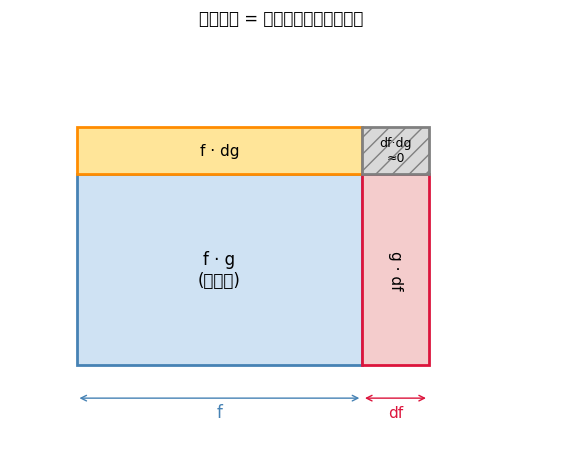

In [3]:
# === 實驗 2-A：把乘積法則畫出來 ===
fig, ax = plt.subplots(figsize=(7, 7))

f_val, g_val = 3.0, 2.0
df, dg = 0.7, 0.5

# 原矩形
ax.add_patch(plt.Rectangle((0, 0), f_val, g_val,
                           facecolor="#cfe2f3", edgecolor="steelblue", linewidth=2))
ax.text(f_val/2, g_val/2, "f · g\n(原面積)", ha="center", va="center", fontsize=12)

# 右側長條：f · dg
ax.add_patch(plt.Rectangle((0, g_val), f_val, dg,
                           facecolor="#ffe599", edgecolor="darkorange", linewidth=2))
ax.text(f_val/2, g_val + dg/2, "f · dg",
        ha="center", va="center", fontsize=11)

# 下方長條：g · df
ax.add_patch(plt.Rectangle((f_val, 0), df, g_val,
                           facecolor="#f4cccc", edgecolor="crimson", linewidth=2))
ax.text(f_val + df/2, g_val/2, "g · df",
        ha="center", va="center", fontsize=11, rotation=-90)

# 右上小方塊：df · dg（高階小量）
ax.add_patch(plt.Rectangle((f_val, g_val), df, dg,
                           facecolor="#d9d9d9", edgecolor="gray", linewidth=2,
                           hatch="//"))
ax.text(f_val + df/2, g_val + dg/2, "df·dg\n≈0",
        ha="center", va="center", fontsize=9)

# 標尺
ax.annotate("", xy=(f_val, -0.35), xytext=(0, -0.35),
            arrowprops=dict(arrowstyle="<->", color="steelblue"))
ax.text(f_val/2, -0.55, "f", ha="center", color="steelblue", fontsize=12)
ax.annotate("", xy=(f_val + df, -0.35), xytext=(f_val, -0.35),
            arrowprops=dict(arrowstyle="<->", color="crimson"))
ax.text(f_val + df/2, -0.55, "df", ha="center", color="crimson", fontsize=11)

ax.set_xlim(-0.7, 5)
ax.set_ylim(-1, 3.5)
ax.set_aspect("equal")
ax.set_title("乘積法則 = 面積增加量的三塊分解")
ax.axis("off")
plt.show()

In [4]:
# === 實驗 2-B：乘積法則的數值驗證 ===
def f(x): return x ** 2          # f'(x) = 2x
def g(x): return np.sin(x)       # g'(x) = cos(x)
def fg_prod(x): return f(x) * g(x)

x0 = 1.5

lhs = central_diff(fg_prod, x0)                                   # (fg)'(x)
rhs = central_diff(f, x0) * g(x0) + f(x0) * central_diff(g, x0)   # f'g + fg'
analytic = 2*x0 * np.sin(x0) + x0**2 * np.cos(x0)

print(f"在 x = {x0}：")
print(f"  (fg)'(x)          = {lhs:.10f}")
print(f"  f'g + fg'         = {rhs:.10f}")
print(f"  解析 2x·sin + x²·cos = {analytic:.10f}")
print(f"  誤差              = {abs(lhs - rhs):.2e}  ✓")
print()
# 反例：證明 (fg)' != f'·g'
print(f"反例驗證：(fg)' ≠ f'·g'")
print(f"  f'(x) · g'(x)    = {central_diff(f, x0) * central_diff(g, x0):.10f}  ← 完全錯！")

在 x = 1.5：
  (fg)'(x)          = 3.1516436634
  f'g + fg'         = 3.1516436636
  解析 2x·sin + x²·cos = 3.1516436636
  誤差              = 1.49e-10  ✓

反例驗證：(fg)' ≠ f'·g'
  f'(x) · g'(x)    = 0.2122116050  ← 完全錯！


## Part 3：鏈式法則——「速度乘以速度」

### 理論

設 $h(x) = g(f(x))$，也就是先把 $x$ 餵進 $f$，再把結果餵進 $g$。則

$$h'(x) = g'(f(x)) \cdot f'(x)$$

### 直觀：兩個齒輪

把 $f$ 想成一個「**轉速器**」——你以速度 $\frac{dx}{dt}$ 推 $x$，它就以 $f'(x) \cdot \frac{dx}{dt}$ 的速度推出 $f(x)$。再把 $g$ 想成另一個轉速器——它對 $f$ 的敏感度是 $g'(f)$。

把兩個齒輪串起來，**整個鏈條的轉速 = 每一節的轉速相乘**：

$$\frac{dh}{dx} = \underbrace{\frac{dh}{df}}_{=g'(f)} \cdot \underbrace{\frac{df}{dx}}_{=f'(x)}$$

### Leibniz 記號的優雅

$$\frac{dh}{dx} = \frac{dh}{df} \cdot \frac{df}{dx}$$

看起來像是分數的「$df$ 上下消掉」。**這不是巧合**——Leibniz 設計這個記號就是要讓鏈式法則看起來像「分數相乘」，讓你可以靠「形式上的代數操作」來提示自己在做什麼。

### 例子

$h(x) = \sin(x^2)$
- 內層 $f(x) = x^2$，$f'(x) = 2x$
- 外層 $g(u) = \sin(u)$，$g'(u) = \cos(u)$
- 所以 $h'(x) = \cos(x^2) \cdot 2x$

In [5]:
# === 實驗 3：鏈式法則的數值驗證 ===
def inner(x): return x ** 2       # f(x) = x²,  f'(x) = 2x
def outer(u): return np.sin(u)    # g(u) = sin u, g'(u) = cos u
def composed(x): return outer(inner(x))   # h(x) = sin(x²)

x0 = 1.5

lhs = central_diff(composed, x0)                              # h'(x) 直接算
rhs = central_diff(outer, inner(x0)) * central_diff(inner, x0)  # g'(f(x)) · f'(x)
analytic = np.cos(x0**2) * 2 * x0                              # cos(x²) · 2x

print(f"h(x) = sin(x²)，在 x = {x0}：")
print(f"  h'(x) 直接算              = {lhs:.10f}")
print(f"  g'(f(x)) · f'(x) 鏈式法則 = {rhs:.10f}")
print(f"  解析 cos(x²)·2x          = {analytic:.10f}")
print(f"  誤差                     = {abs(lhs - rhs):.2e}  ✓")

print("\n--- 再試一個：h(x) = e^(x²) ---")
def h2(x): return np.exp(x ** 2)
analytic2 = np.exp(x0**2) * 2 * x0
print(f"  h'(x) 直接算          = {central_diff(h2, x0):.6f}")
print(f"  解析 e^(x²)·2x        = {analytic2:.6f}")

h(x) = sin(x²)，在 x = 1.5：
  h'(x) 直接算              = -1.8845208681
  g'(f(x)) · f'(x) 鏈式法則 = -1.8845208682
  解析 cos(x²)·2x          = -1.8845208682
  誤差                     = 4.01e-11  ✓

--- 再試一個：h(x) = e^(x²) ---
  h'(x) 直接算          = 28.463208
  解析 e^(x²)·2x        = 28.463208


## Part 4：視覺化——複合函數的導數長什麼樣？

把 $h(x) = \sin(x^2)$ 與它的導數 $h'(x) = 2x\cos(x^2)$ 並排畫出來，再用數值微分覆蓋，三條應該重合。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_58806/96489808.py:22: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_58806/96489808.py:22: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_58806/96489808.py:22: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_58806/96489808.py:22: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_58806/96489808.py:22: UserWarning: Glyph 37832 (\N{CJK UNIFIED IDEOGRAPH-93C8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1s

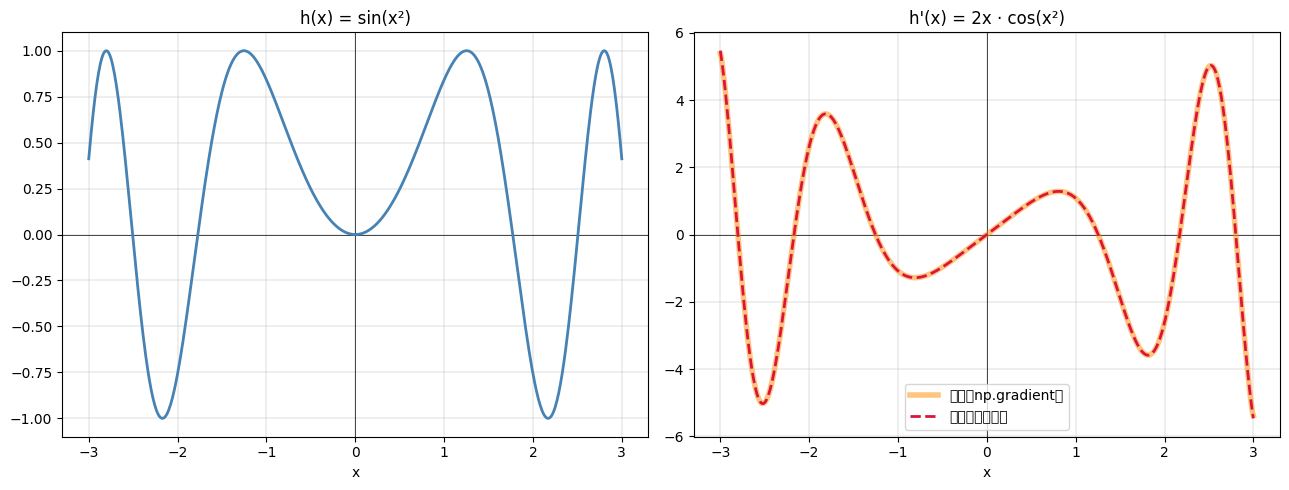

全域最大誤差：8.64e-02


In [6]:
# === 實驗 4：複合函數視覺化 ===
xs = np.linspace(-3, 3, 600)

h_vals          = np.sin(xs ** 2)
h_deriv_chain   = 2 * xs * np.cos(xs ** 2)        # 鏈式法則解析解
h_deriv_numeric = np.gradient(h_vals, xs)         # 純數值（中央差分）

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

setup_ax(axes[0], title="h(x) = sin(x²)")
axes[0].plot(xs, h_vals, color="steelblue", linewidth=2)
axes[0].set_xlabel("x")

setup_ax(axes[1], title="h'(x) = 2x · cos(x²)")
axes[1].plot(xs, h_deriv_numeric, color="darkorange",
             linewidth=4, alpha=0.5, label="數值（np.gradient）")
axes[1].plot(xs, h_deriv_chain, "--", color="crimson",
             linewidth=2, label="鏈式法則解析解")
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()
plt.show()

err = np.max(np.abs(h_deriv_chain - h_deriv_numeric))
print(f"全域最大誤差：{err:.2e}")

觀察：
- 隨著 $|x|$ 變大，$x^2$ 增長更快，$\sin(x^2)$ 振盪頻率越高——導數的振幅也越大（被 $2x$ 放大）
- 數值與解析幾乎完美重合，鏈式法則 ✓

## Part 5：手寫迷你 autograd——10 行 Python 重現 PyTorch 核心

PyTorch 的 `loss.backward()` 看起來像魔法，但其核心就是**鏈式法則的機械化**。我們現在自己寫一個。

### 設計

每個變數 `Var` 記住三件事：
1. 它的**值**（forward pass 的結果）
2. 它的**父節點**（用什麼運算算出來的）
3. 對每個父節點的**局部梯度**（鏈式法則裡那個 $\partial \text{out} / \partial \text{parent}$）

`backward()` 從最末端往回走，把梯度**累加**到每個父節點上——這就是反向傳播。

In [7]:
# === 實驗 5-A：迷你 autograd Var 類別 ===
class Var:
    def __init__(self, value, parents=()):
        self.value = float(value)
        self.grad = 0.0
        self.parents = parents  # list of (parent_var, local_grad)

    def __add__(self, other):
        other = other if isinstance(other, Var) else Var(other)
        return Var(self.value + other.value,
                   parents=[(self, 1.0), (other, 1.0)])

    def __mul__(self, other):
        other = other if isinstance(other, Var) else Var(other)
        return Var(self.value * other.value,
                   parents=[(self, other.value), (other, self.value)])

    __radd__ = __add__
    __rmul__ = __mul__

    def sin(self):
        return Var(np.sin(self.value),
                   parents=[(self, np.cos(self.value))])

    def exp(self):
        v = np.exp(self.value)
        return Var(v, parents=[(self, v)])

    def __pow__(self, n):
        return Var(self.value ** n,
                   parents=[(self, n * self.value ** (n - 1))])

    def backward(self, grad=1.0):
        """鏈式法則的機械化：把 grad 沿樹根往葉子推。"""
        self.grad += grad
        for parent, local in self.parents:
            parent.backward(grad * local)


print("Var class loaded ✓")

Var class loaded ✓


In [8]:
# === 實驗 5-B：用 Var 算 sin(x²) 的導數 ===
x = Var(1.5)
y = (x ** 2).sin()         # 計算圖：x → x² → sin(x²)

# Forward 結果
print(f"forward: y = sin(x²) = {y.value:.10f}")
print(f"         np.sin(1.5²) = {np.sin(1.5**2):.10f}")
print()

# Backward：鏈式法則自動發生
y.backward()
print(f"x.grad（autograd）       = {x.grad:.10f}")
print(f"解析 cos(x²)·2x         = {np.cos(1.5**2) * 2 * 1.5:.10f}")
print(f"誤差                    = {abs(x.grad - np.cos(1.5**2)*2*1.5):.2e}  ✓")

forward: y = sin(x²) = 0.7780731969
         np.sin(1.5²) = 0.7780731969

x.grad（autograd）       = -1.8845208682
解析 cos(x²)·2x         = -1.8845208682
誤差                    = 0.00e+00  ✓


In [9]:
# === 實驗 5-C：更複雜的計算圖 ===
# h(x) = x² · sin(x) + e^x   ← 同時用到乘積、鏈式、加法
x = Var(0.8)
h = (x ** 2) * x.sin() + x.exp()

print(f"forward: h = {h.value:.10f}")
analytic_h = 0.8**2 * np.sin(0.8) + np.exp(0.8)
print(f"        解析 = {analytic_h:.10f}")

h.backward()
# h'(x) = 2x·sin(x) + x²·cos(x) + e^x
analytic_dh = 2*0.8*np.sin(0.8) + 0.8**2*np.cos(0.8) + np.exp(0.8)
print(f"\nx.grad（autograd） = {x.grad:.10f}")
print(f"解析 h'(x)         = {analytic_dh:.10f}")
print(f"誤差                = {abs(x.grad - analytic_dh):.2e}  ✓")

forward: h = 2.6846488267
        解析 = 2.6846488267

x.grad（autograd） = 3.8192029679
解析 h'(x)         = 3.8192029679
誤差                = 0.00e+00  ✓


**這就是 PyTorch / JAX 的核心**——每個運算記住自己的局部梯度，`backward()` 沿計算圖逆向把梯度乘起來。差別只是：
- 真正的 autograd 支援**張量**（不只是純量）
- 真正的 autograd 用 **topological sort** 避免重複計算
- 真正的 autograd 有 GPU、JIT、多種 dtype……

但**演算法本質**就是上面這 30 行。

## Part 6：練習區 🏋️

試著用上面的 `Var` 類別計算這些函數的導數，跟解析解比較：

1. $h(x) = \sin(\sin(x))$（雙層鏈式）
2. $h(x) = (x + 1)^3 \cdot e^{-x}$（乘積 + 鏈式 + 鏈式）
3. $h(x) = x \cdot \sin(x^2)$（你最愛的那個）

In [10]:
# ===== 練習：自己組合函數 =====
# ✏️ 改下面的 expression，看 autograd 給的導數和你心算的一不一樣

x = Var(0.7)
expr = ((x + 1.0) ** 3) * (Var(0).exp() * Var(1))  # 佔位，請改我！
# 例如：expr = (x ** 2).sin() + x * x.exp()

# 上面那個會計算 (x+1)^3 * 1，因為 e^0 * 1 = 1。改成你想要的式子。

print(f"x       = {x.value}")
print(f"y       = {expr.value:.6f}")
expr.backward()
print(f"dy/dx   = {x.grad:.6f}")

# 用中央差分檢查
def my_func(xv):
    return ((xv + 1.0) ** 3)  # 對應上面 expr 化簡後的形式

numeric = central_diff(my_func, 0.7)
print(f"中央差分 = {numeric:.6f}")
print(f"誤差     = {abs(x.grad - numeric):.2e}")

x       = 0.7
y       = 4.913000
dy/dx   = 8.670000
中央差分 = 8.670000
誤差     = 2.27e-11


## Part 7：總結 & 深度學習連結

### 三條法則一表帶走

| 法則 | 公式 | 直觀 |
|---|---|---|
| 加法 | $(f+g)' = f' + g'$ | 兩個變化獨立疊加 |
| 乘積 | $(fg)' = f'g + fg'$ | 矩形面積擴張：「寬變」+「高變」 |
| 鏈式 | $g(f(x))' = g'(f(x)) \cdot f'(x)$ | 兩個齒輪串聯，轉速相乘 |

<br>

### 連到深度學習

| 微積分 | DL 對應 |
|---|---|
| **鏈式法則** | **反向傳播 (backpropagation)**——一個 N 層網路的梯度，就是 N 個局部梯度的乘積 |
| 乘積法則 | 一層神經元 $y = w \cdot x$ 的梯度推導：$\partial L / \partial w = (\partial L / \partial y) \cdot x$ |
| Leibniz 記號 $\frac{dh}{dx} = \frac{dh}{df}\frac{df}{dx}$ | DL 教材寫的 $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y}\frac{\partial y}{\partial w}$ 完全是同一件事 |
| 「梯度 = 沿路局部梯度的連乘」 | **梯度消失 / 梯度爆炸**：N 層網路的梯度是 N 個數連乘，全 < 1 → 消失，全 > 1 → 爆炸 |
| autograd 機械化鏈式法則 | PyTorch `loss.backward()` 的實作核心 |

<br>

### 為什麼 ReLU 拯救了深度學習？

對 sigmoid，$\sigma'(z) \le 0.25$。一個 10 層的網路，反向傳播算梯度時要乘 10 次，最大也只能到 $0.25^{10} \approx 10^{-6}$——**梯度幾乎為 0，學不動**。

ReLU 的導數要嘛是 0 要嘛是 1，連乘**不會自動變小**。這個觀察直接來自鏈式法則。

<br>

### 下一步

- **Ch 5 指數函數求導**：為什麼 $\frac{d}{dx}e^x = e^x$？這是 $e$ 的「定義」
- **Ch 7 極限**：嚴格化「$dx \to 0$」這件事，認識 $\epsilon$-$\delta$
- **Ch 11 泰勒級數**：把任何函數展成多項式——Adam、牛頓法的數學基礎